<center> <img src = https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/hh%20label.jpg alt="drawing" style="width:400px;">

# <center> Проект: Анализ вакансий из HeadHunter
   

In [570]:
import pandas as pd
import psycopg2

In [ ]:
# вставьте сюда параметры подключения из юнита 1. Работа с базой данных из Python


In [572]:
connection = psycopg2.connect(
    dbname=DBNAME,
    user=USER,
    host=HOST,
    password=PASSWORD,
    port=PORT
)

# Юнит 3. Предварительный анализ данных

1. Напишите запрос, который посчитает количество вакансий в нашей базе (вакансии находятся в таблице vacancies). 

In [573]:
# текст запроса
query_3_1 = f'''SELECT count(*)
FROM vacancies;
'''


In [574]:
df = pd.read_sql_query(query_3_1, connection)
df

C:\Users\Klic\AppData\Local\Temp\ipykernel_4700\3851344990.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_3_1, connection)


,count
0,49197


2. Напишите запрос, который посчитает количество работодателей (таблица employers). 

In [575]:
query_3_2 = f'''SELECT count(*)
FROM employers;
'''

In [576]:
df = pd.read_sql_query(query_3_2, connection)
df

C:\Users\Klic\AppData\Local\Temp\ipykernel_4700\3588252056.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_3_2, connection)


,count
0,23501


3. Посчитате с помощью запроса количество регионов (таблица areas).

In [577]:
query_3_3 = f'''SELECT count(*)
FROM areas;
'''

In [578]:
df = pd.read_sql_query(query_3_3, connection)
df

C:\Users\Klic\AppData\Local\Temp\ipykernel_4700\2018224393.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_3_3, connection)


,count
0,1362


4. Посчитате с помощью запроса количество сфер деятельности в базе (таблица industries).

In [579]:
query_3_4 = f'''SELECT count(*)
FROM industries;
'''

In [580]:
df = pd.read_sql_query(query_3_4, connection)
df

C:\Users\Klic\AppData\Local\Temp\ipykernel_4700\2172479966.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_3_4, connection)


,count
0,294


Общие выводы:
* В среднем на каждого работадателя приходится 2,09 вакансии (49 197 вакансий / 23 501 работадетели).
* Это или мальнькие фирмы или сейчас неактивная фаза поиска.
* В среднем на один регион приходится 36 вакансий (49 197 вакансий / 1 362 регионов )
* В среднем в каждом регионе представлено около 17 работодателей (23 501 вакансий / 1 362 регионов)
* Стоит уточнить:  в данных есть регионы-лидеры (Москва,, Санкт-Петербург), то скорее всего ~ 50 % вакансий приходиться на них

***

# Юнит 4. Детальный анализ вакансий

1. Напишите запрос, который позволит узнать, сколько (cnt) вакансий в каждом регионе (area).
Отсортируйте по количеству вакансий в порядке убывания.

In [581]:
query_4_1 = f'''SELECT a.name,count(a.name)
FROM public.areas as a
-- Внутреннее соединение с таблицей вакансий по идентификатору региона
INNER JOIN public.vacancies as v ON v.area_id = a.id
-- Группируем по названию региона
GROUP BY a.name
-- Сортируем по убыванию количества вакансий
ORDER BY COUNT(a.name) DESC;'''

In [582]:
df = pd.read_sql_query(query_4_1, connection)
df

C:\Users\Klic\AppData\Local\Temp\ipykernel_4700\347208320.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_4_1, connection)


,name,count
0,Москва,5333
1,Санкт-Петербург,2851
2,Минск,2112
3,Новосибирск,2006
4,Алматы,1892
...,...,...
764,Тарко-Сале,1
765,Новоаннинский,1
766,Бирск,1
767,Сасово,1


2. Напишите запрос, чтобы определить у какого количества вакансий заполнено хотя бы одно из двух полей с зарплатой.

In [583]:
query_4_2 = f'''SELECT count(name)
FROM vacancies AS v
-- Условие: оставляем только вакансии, у которых заполнена
WHERE v.salary_from IS NOT NULL OR v.salary_to IS NOT NULL;'''

In [584]:
df = pd.read_sql_query(query_4_2, connection)
df

C:\Users\Klic\AppData\Local\Temp\ipykernel_4700\2168503709.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_4_2, connection)


,count
0,24073


3. Найдите средние значения для нижней и верхней границы зарплатной вилки. Округлите значения до целого.

In [585]:
query_4_3 = f'''SELECT ROUND(AVG(v.salary_from)) AS "Нижняя планка",ROUND(AVG(v.salary_to)) AS "Верхняя планка"

FROM vacancies AS v
-- Учитываем только вакансии, где заполнена хотя бы одна граница зарплаты
WHERE v.salary_from IS NOT NULL OR v.salary_to IS NOT NULL;'''

In [586]:
df = pd.read_sql_query(query_4_3, connection)
df

C:\Users\Klic\AppData\Local\Temp\ipykernel_4700\2222372203.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_4_3, connection)


,Нижняя планка,Верхняя планка
0,71065.0,110537.0


4. Напишите запрос, который выведет количество вакансий для каждого сочетания типа рабочего графика (schedule) и типа трудоустройства (employment), используемого в вакансиях. Результат отсортируйте по убыванию количества.


In [587]:
query_4_4 = f'''SELECT v.schedule, v.employment,count(v.schedule)
FROM public.vacancies as v
-- Группируем по уникальным парам (schedule, employment)
GROUP BY v.schedule, v.employment
-- Сортируем по убыванию количества вакансий
ORDER BY COUNT(v.schedule) DESC;'''

In [588]:
df = pd.read_sql_query(query_4_4, connection)
df

C:\Users\Klic\AppData\Local\Temp\ipykernel_4700\2981602351.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_4_4, connection)


,schedule,employment,count
0,Полный день,Полная занятость,35367
1,Удаленная работа,Полная занятость,7802
2,Гибкий график,Полная занятость,1593
3,Удаленная работа,Частичная занятость,1312
4,Сменный график,Полная занятость,940
5,Полный день,Стажировка,569
6,Вахтовый метод,Полная занятость,367
7,Полный день,Частичная занятость,347
8,Гибкий график,Частичная занятость,312
9,Полный день,Проектная работа,141


5. Напишите запрос, выводящий значения поля Требуемый опыт работы (experience) в порядке возрастания количества вакансий, в которых указан данный вариант опыта. 

In [589]:
query_4_5 = f'''SELECT v.experience, count(v.experience)
FROM public.vacancies as v
-- Группируем строки по уникальным значениям поля experience
GROUP BY v.experience
-- Сортируем результат по возрастанию количества вакансий
ORDER BY COUNT(v.experience);'''

In [590]:
df_experience = pd.read_sql_query(query_4_5, connection)
df_experience

C:\Users\Klic\AppData\Local\Temp\ipykernel_4700\854704288.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_experience = pd.read_sql_query(query_4_5, connection)


,experience,count
0,Более 6 лет,1337
1,Нет опыта,7197
2,От 3 до 6 лет,14511
3,От 1 года до 3 лет,26152


***

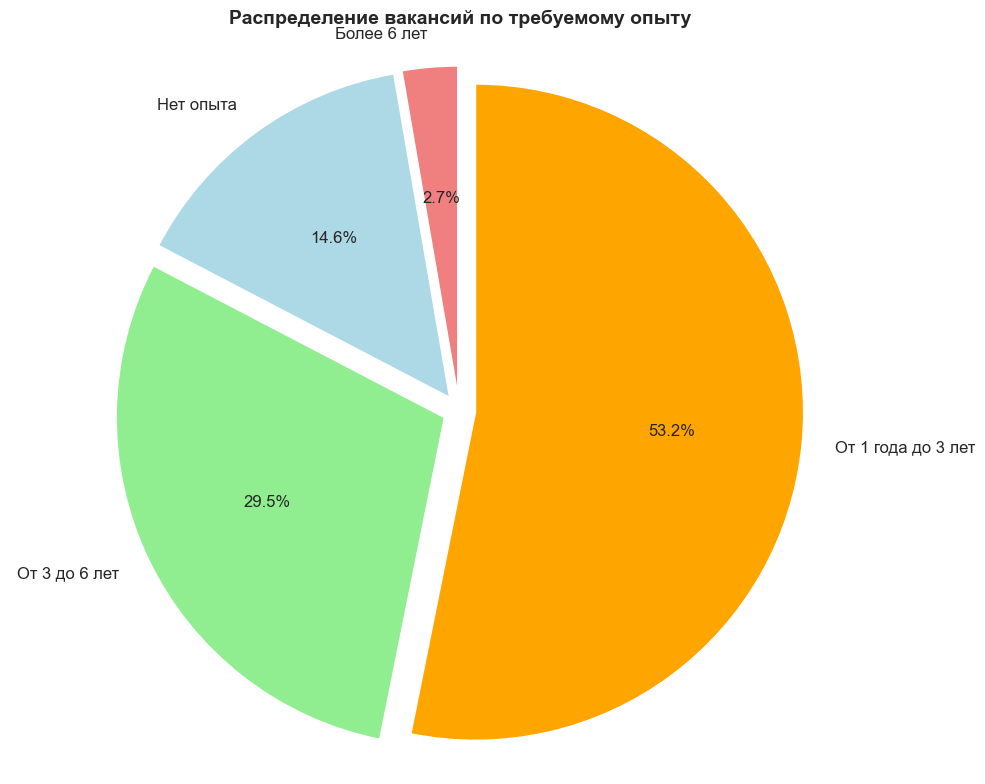

In [591]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Данные из query_4_5
experience_data = df_experience
# Распределение вакансий по требуемому опыту

colors = ['lightcoral', 'lightblue', 'lightgreen', 'orange']
plt.figure(figsize=(10, 8))
plt.pie(experience_data['count'], labels=experience_data['experience'],
        autopct='%1.1f%%', startangle=90, colors=colors,
        explode=(0.05, 0.05, 0.05, 0.05))
plt.title('Распределение вакансий по требуемому опыту', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.savefig('experience_pie.png', dpi=150, bbox_inches='tight')
plt.show()


* География - Сильная концентрация в Москве и Санкт-Петербурге
* Зарплата - Указана только в ~49% вакансий; средняя вилка 71–111 тыс. руб.
* Формат - работы	Доминирует полный день + полная занятость (72%), удалёнка набирает обороты (16%)
* Опыт -Основной спрос — на специалистов с опытом 1–3 года (53%)
* Вход в профессию - Около 15% вакансий доступны без опыта (стажировки, junior-позиции)


# Юнит 5. Анализ работодателей

1. Напишите запрос, который позволит узнать, какие работодатели находятся на первом и пятом месте по количеству вакансий.

In [592]:
query_5_1 = f"""SELECT
    name AS "Имя",
    vacancies_count AS "кол-во вакансий",
    rank as "Место"

FROM (
    -- Подзапрос: ранжируем работодателей по количеству вакансий
    SELECT
        e.name,                                    -- Название работодателя
        COUNT(v.id) as vacancies_count,            -- Количество вакансий
        -- Присваиваем ранг (место) по убыванию количества вакансий
        RANK() OVER (ORDER BY COUNT(v.id) DESC) as rank
    FROM public.employers as e
    INNER JOIN public.vacancies as v ON v.employer_id = e.id
    GROUP BY e.name                                -- Группируем по работодателю
) ranked_employers

-- Оставляем только 1-е и 5-е места
WHERE rank IN (1, 5)

-- Сортируем по рангу (сначала 1-е место, потом 5-е)
ORDER BY rank;"""

In [593]:
df = pd.read_sql_query(query_5_1, connection)
df

C:\Users\Klic\AppData\Local\Temp\ipykernel_4700\1792814825.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_5_1, connection)


,Имя,кол-во вакансий,Место
0,Яндекс,1933,1
1,Газпром нефть,331,5


2. Напишите запрос, который для каждого региона выведет количество работодателей и вакансий в нём.
Среди регионов, в которых нет вакансий, найдите тот, в котором наибольшее количество работодателей.


In [594]:
query_5_2 = f"""SELECT
    a.name,
    COUNT(e.id) as employers_count

FROM public.areas a
LEFT JOIN public.employers e ON e.area = a.id
LEFT JOIN public.vacancies v ON v.area_id = a.id

-- Группируем по каждому региону
GROUP BY a.id, a.name

-- Оставляем только регионы, в которых нет ни одной вакансии
HAVING COUNT(v.id) = 0

-- Сортируем по количеству работодателей
ORDER BY COUNT(e.id) DESC

-- Берём первый регион
LIMIT 1;"""

In [595]:
df = pd.read_sql_query(query_5_2, connection)
df

C:\Users\Klic\AppData\Local\Temp\ipykernel_4700\3341481329.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_5_2, connection)


,name,employers_count
0,Россия,410


3. Для каждого работодателя посчитайте количество регионов, в которых он публикует свои вакансии. Отсортируйте результат по убыванию количества.


In [596]:
query_5_3 = f"""SELECT
    e.id,
    e.name as employer_name,
    COUNT(DISTINCT v.area_id) as regions_count


FROM public.employers e
INNER JOIN public.vacancies v ON v.employer_id = e.id

-- Группируем по каждому работодателю
GROUP BY e.id, e.name

-- Сортируем по убыванию количества регионов
ORDER BY regions_count DESC;"""

In [597]:
df = pd.read_sql_query(query_5_3, connection)
df

C:\Users\Klic\AppData\Local\Temp\ipykernel_4700\2398953733.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_5_3, connection)


,id,employer_name,regions_count
0,1740,Яндекс,181
1,2748,Ростелеком,152
2,5724811,Спецремонт,116
3,5130287,Поляков Денис Иванович,88
4,3682876,ООО ЕФИН,71
...,...,...,...
14901,810278,НПП Авиатрон,1
14902,810313,Центр дистанционных торгов,1
14903,810551,Городские Телекоммуникационные Системы,1
14904,810688,"Введенский, Отель",1


4. Напишите запрос для подсчёта количества работодателей, у которых не указана сфера деятельности. 

In [598]:
query_5_4 = f"""SELECT
    -- Подсчитываем количество работодателей без сфер деятельности
    COUNT(e.name) AS "кол-во"

-- Источник данных: таблица с работодателями
FROM public.employers AS e
LEFT JOIN employers_industries AS ei ON ei.employer_id = e.id

-- Присоединяем таблицу со сферами деятельности
LEFT JOIN public.industries AS i ON ei.industry_id = i.id

-- Оставляем только тех работодателей, у которых НЕТ сфер деятельности
WHERE i.id IS NULL;"""

In [599]:
df = pd.read_sql_query(query_5_4, connection)
df

C:\Users\Klic\AppData\Local\Temp\ipykernel_4700\3114411492.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_5_4, connection)


,кол-во
0,8419


5. Напишите запрос, чтобы узнать название компании, находящейся на третьем месте в алфавитном списке (по названию) компаний, у которых указано четыре сферы деятельности. 

In [600]:
query_5_5 = f"""SELECT
    e.name   -- Название компании (работодателя)

-- Источник данных: таблица с работодателями
FROM public.employers AS e
LEFT JOIN employers_industries AS ei ON ei.employer_id = e.id
LEFT JOIN public.industries AS i ON ei.industry_id = i.id

-- Группируем по каждому работодателю (чтобы считать количество сфер)
GROUP BY e.id, e.name

-- Оставляем только тех работодателей, у которых ровно 4 уникальные сферы деятельности
HAVING COUNT(DISTINCT ei.industry_id) = 4

-- Сортируем по алфавиту
ORDER BY e.name

-- Пропускаем первые 2 записи и берём 3-ю
LIMIT 1 OFFSET 2;"""

In [601]:
df = pd.read_sql_query(query_5_5, connection)
df

C:\Users\Klic\AppData\Local\Temp\ipykernel_4700\1650419958.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_5_5, connection)


,name
0,2ГИС


6. С помощью запроса выясните, у какого количества работодателей в качестве сферы деятельности указана Разработка программного обеспечения.


In [602]:
query_5_6 = f"""SELECT
    -- Подсчитываем количество уникальных работодателей
    COUNT(e.name) AS "Кол-во"

-- Источник данных: таблица с работодателями
FROM public.employers AS e

-- Присоединяем связочную таблицу (работодатели → сферы деятельности)
LEFT JOIN employers_industries AS ei ON ei.employer_id = e.id

-- Присоединяем таблицу со сферами деятельности
LEFT JOIN public.industries AS i ON ei.industry_id = i.id

-- Оставляем только работодателей из сферы "Разработка программного обеспечения"
WHERE i.name = 'Разработка программного обеспечения';"""

In [603]:
df = pd.read_sql_query(query_5_6, connection)
df

C:\Users\Klic\AppData\Local\Temp\ipykernel_4700\1169039133.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_5_6, connection)


,Кол-во
0,3553


7. Для компании «Яндекс» выведите список регионов-миллионников, в которых представлены вакансии компании, вместе с количеством вакансий в этих регионах. Также добавьте строку Total с общим количеством вакансий компании. Результат отсортируйте по возрастанию количества.

Список городов-милионников надо взять [отсюда](https://ru.wikipedia.org/wiki/%D0%93%D0%BE%D1%80%D0%BE%D0%B4%D0%B0-%D0%BC%D0%B8%D0%BB%D0%BB%D0%B8%D0%BE%D0%BD%D0%B5%D1%80%D1%8B_%D0%A0%D0%BE%D1%81%D1%81%D0%B8%D0%B8). 

Если возникнут трудности с этим задание посмотрите материалы модуля  PYTHON-17. Как получать данные из веб-источников и API. 

In [604]:
import pandas as pd

# Заголовки для имитации запроса от браузера (чтобы избежать блокировки)
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
}

# URL страницы Википедии со списком городов-миллионеров

url = 'https://ru.wikipedia.org/wiki/%D0%93%D0%BE%D1%80%D0%BE%D0%B4%D0%B0-%D0%BC%D0%B8%D0%BB%D0%BB%D0%B8%D0%BE%D0%BD%D0%B5%D1%80%D1%8B_%D0%A0%D0%BE%D1%81%D1%81%D0%B8%D0%B8'


# Читаем все HTML-таблицы со страницы
tables = pd.read_html(url, storage_options=headers)

# Инициализируем переменную для списка городов
cities = None

for table in tables:
    if len(table) >= 16 and 'Город' in table.columns:
        # Берём первые 16 строк из второго столбца (названия городов)
        cities = table.iloc[:16, 1].tolist()
        break

if cities is None:
    for table in tables:
        col = table.iloc[:, 1]  # Второй столбец
        # Проверяем, что первые 16 значений — строки
        if len(col) >= 16 and col[:16].apply(lambda x: isinstance(x, str)).all():
            cities = col[:16].tolist()
            break

# Формируем строку для подстановки
cities_str = ', '.join([f"'{city}'" for city in cities])


In [605]:
query_5_7 = f"""SELECT
    region_name,
    vacancies_count

FROM (
    -- Данные по каждому городу-миллионеру
    SELECT
        a.name as region_name,              -- Название региона
        COUNT(v.id) as vacancies_count,     -- Количество вакансий Яндекса
        0 as sort_order                     -- Флаг сортировки (города — первыми)
    FROM public.vacancies v
    LEFT JOIN public.areas a ON v.area_id = a.id        -- Присоединяем регионы
    LEFT JOIN public.employers e ON v.employer_id = e.id -- Присоединяем работодателей
    WHERE a.name IN ({cities_str})          -- Только города-миллионеры
        AND e.name = 'Яндекс'               -- Только вакансии Яндекса
    GROUP BY a.id, a.name                   -- Группируем по каждому региону

    UNION ALL

    -- Итоговая строка Total
    SELECT
        'Total',                            -- Строка-маркер итога
        COUNT(v.id),                        -- Общее количество вакансий
        1 as sort_order                     -- Флаг сортировки (Total — последним)
    FROM public.vacancies v
    LEFT JOIN public.areas a ON v.area_id = a.id        -- Присоединяем регионы
    LEFT JOIN public.employers e ON v.employer_id = e.id -- Присоединяем работодателей
    WHERE a.name IN ({cities_str})          -- Только города-миллионеры
        AND e.name = 'Яндекс'

) t
ORDER BY
    sort_order,
    vacancies_count DESC; """

In [606]:
df = pd.read_sql_query(query_5_7, connection)
df

C:\Users\Klic\AppData\Local\Temp\ipykernel_4700\3129374555.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_5_7, connection)


,region_name,vacancies_count
0,Москва,54
1,Санкт-Петербург,42
2,Екатеринбург,39
3,Нижний Новгород,36
4,Новосибирск,35
5,Воронеж,32
6,Краснодар,30
7,Самара,26
8,Уфа,26
9,Казань,25


***

C:\Users\Klic\AppData\Local\Temp\ipykernel_4700\681049031.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  top_regions_employers = pd.read_sql_query(top_regions_employers_query, connection)


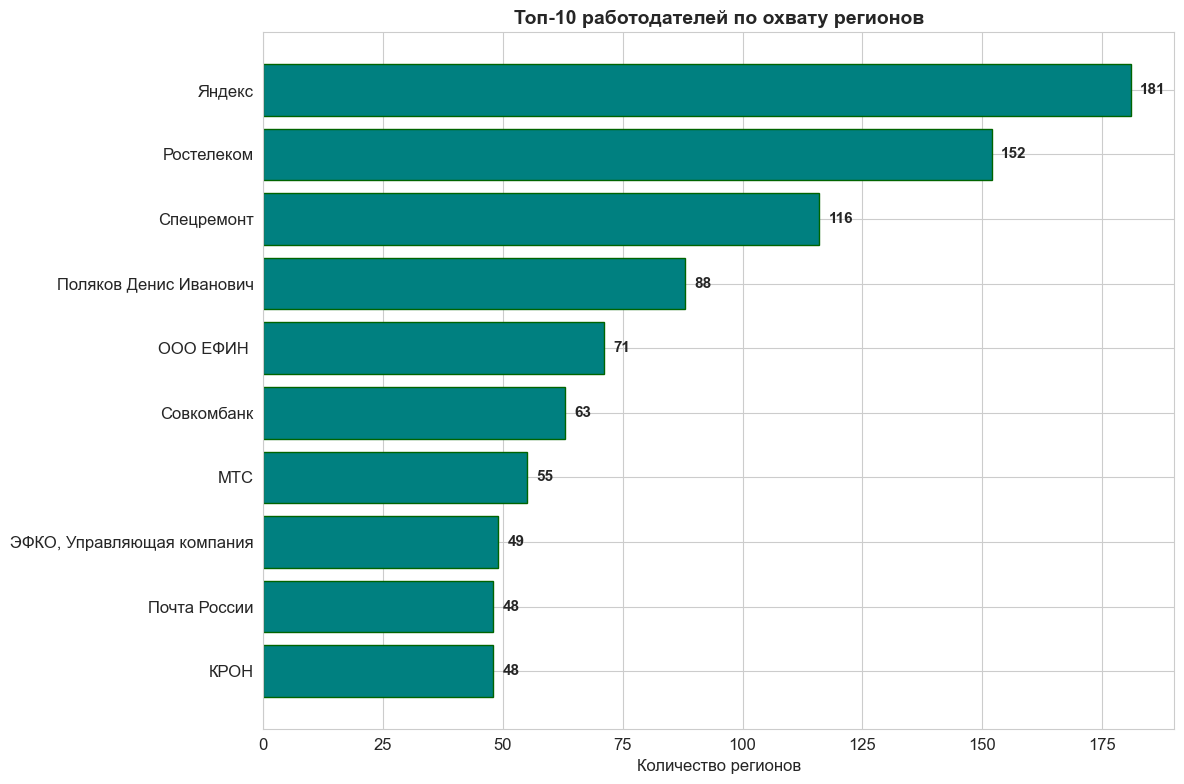

In [607]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Установим стиль для графиков
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
top_regions_employers_query = """
SELECT
    e.name as employer_name,
    COUNT(DISTINCT v.area_id) as regions_count
FROM public.employers e
INNER JOIN public.vacancies v ON v.employer_id = e.id
GROUP BY e.id, e.name
ORDER BY regions_count DESC
LIMIT 10;
"""

top_regions_employers = pd.read_sql_query(top_regions_employers_query, connection)

plt.figure(figsize=(12, 8))
bars = plt.barh(top_regions_employers['employer_name'].iloc[::-1],
                top_regions_employers['regions_count'].iloc[::-1],
                color='teal', edgecolor='darkgreen')
plt.xlabel('Количество регионов', fontsize=12)
plt.title('Топ-10 работодателей по охвату регионов', fontsize=14, fontweight='bold')
for bar in bars:
    width = bar.get_width()
    plt.text(width + 2, bar.get_y() + bar.get_height()/2,
             f'{int(width)}', ha='left', va='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('top10_employers_regions.png', dpi=150, bbox_inches='tight')
plt.show()

Выводы по графику
* Яндекс занимает первое место с большим отрывом — 181 регион. Это на 29 регионов больше, чем у второго места (Ростелеком). Такой широкий охват говорит о:
* Федеральном масштабе компании
* Развитой региональной сети
* Активной политике найма по всей стране

Федеральные гиганты
* Ростелеком (152 региона) и Спецремонт (116 регионов) также демонстрируют впечатляющее присутствие. Это характерно для:
* Государственных и окологосударственных структур
* Компаний с разветвлённой инфраструктурой
* Организаций, оказывающих услуги по всей территории РФ

Неожиданные участники
* Присутствие в топе индивидуального предпринимателя (Поляков Денис Иванович) с 88 регионами выглядит аномально. Возможные объяснения:
* Техническая особенность заполнения данных (один ИП представлен как множество юрлиц)
* Агрессивная стратегия размещения вакансий через различные площадки
* Артефакт базы данных (требует проверки)

Общие выводы:
* Лидер по вакансиям - Яндекс (1 933 вакансии) — значительный отрыв от остальных
* Географический охват - Яндекс — самый широкий (181 регион); большинство компаний локальны (1 регион)
* Проблема данных - 35,8% работодателей не указали сферу деятельности
* Популярная сфера - Разработка ПО — 3 553 работодателя (~15%)
* Регион-артефакт - «Россия» без вакансий, но с 410 работодателями — требует обработки
* Присутствие Яндекса - Во всех 16 городах-миллионерах (всего 485 вакансий)

# Юнит 6. Предметный анализ

1. Сколько вакансий имеет отношение к данным?

Считаем, что вакансия имеет отношение к данным, если в её названии содержатся слова 'data' или 'данн'.

*Подсказка: Обратите внимание, что названия вакансий могут быть написаны в любом регистре.* 


In [608]:
query_6_1 = f"""SELECT
    -- Подсчитываем количество вакансий, удовлетворяющих условиям
    COUNT(*)

-- Источник данных: таблица с вакансиями
FROM public.vacancies as v

-- Условия фильтрации:
WHERE
    -- Ищем вакансии, где в названии есть хотя бы одно из ключевых слов:
    LOWER(v.name) LIKE '%data%'
    OR LOWER(v.name) LIKE '%данн%';"""

In [609]:
df = pd.read_sql_query(query_6_1, connection)
df

C:\Users\Klic\AppData\Local\Temp\ipykernel_4700\485020324.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_6_1, connection)


,count
0,1771


2. Сколько есть подходящих вакансий для начинающего дата-сайентиста? 
Будем считать вакансиями для дата-сайентистов такие, в названии которых есть хотя бы одно из следующих сочетаний:
* 'data scientist'
* 'data science'
* 'исследователь данных'
* 'ML' (здесь не нужно брать вакансии по HTML)
* 'machine learning'
* 'машинн%обучен%'

** В следующих заданиях мы продолжим работать с вакансиями по этому условию.*

Считаем вакансиями для специалистов уровня Junior следующие:
* в названии есть слово 'junior' *или*
* требуемый опыт — Нет опыта *или*
* тип трудоустройства — Стажировка.
 

In [610]:
query_6_2 = f"""SELECT
    -- Подсчитываем количество вакансий, удовлетворяющих всем условиям
    COUNT(*)

-- Источник данных: таблица с вакансиями
FROM public.vacancies as v

-- Условия фильтрации:
WHERE
    -- 1. Отбираем только DS-вакансии по ключевым словам в названии
    ((LOWER(v.name) LIKE '%data scientist%'       -- "data scientist"
      OR LOWER(v.name) LIKE '%data science%'      -- "data science"
      OR LOWER(v.name) LIKE '%исследователь данных%'  -- русский вариант
      OR (LOWER(v.name) LIKE '%ml%' AND LOWER(v.name) NOT LIKE '%html%') -- "ML" (исключая HTML)
      OR LOWER(v.name) LIKE '%machine learning%'  -- "machine learning"
      OR LOWER(v.name) LIKE '%машинн%обучен%'))   -- русский вариант

    -- 2. Среди DS-вакансий отбираем Junior-уровень (хотя бы одно из условий)
    AND (LOWER(v.name) LIKE '%junior%'            -- в названии есть "junior"
         OR LOWER(v.experience) LIKE '%нет опыта%'   -- опыт не требуется
         OR LOWER(v.employment) LIKE '%стажировка%'); -- тип занятости — стажировка"""

In [611]:
df = pd.read_sql_query(query_6_2, connection)
df

C:\Users\Klic\AppData\Local\Temp\ipykernel_4700\3641650667.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_6_2, connection)


,count
0,51


3. Сколько есть вакансий для DS, в которых в качестве ключевого навыка указан SQL или postgres?

** Критерии для отнесения вакансии к DS указаны в предыдущем задании.*

In [612]:
query_6_3 = f"""SELECT
    -- Подсчитываем количество вакансий, удовлетворяющих условиям
    COUNT(*)

-- Источник данных: таблица с вакансиями
FROM public.vacancies as v

-- Условия фильтрации:
WHERE
    -- 1. Отбираем только DS-вакансии по ключевым словам в названии
    ((LOWER(v.name) LIKE '%data scientist%'       -- "data scientist"
      OR LOWER(v.name) LIKE '%data science%'      -- "data science"
      OR LOWER(v.name) LIKE '%исследователь данных%'  -- русский вариант
      OR (LOWER(v.name) LIKE '%ml%' AND LOWER(v.name) NOT LIKE '%html%') -- "ML" (исключая HTML)
      OR LOWER(v.name) LIKE '%machine learning%'  -- "machine learning"
      OR LOWER(v.name) LIKE '%машинн%обучен%'))   -- русский вариант

    -- 2. Среди них оставляем только те, где в ключевых навыках указан SQL или PostgreSQL
    AND (LOWER(v.key_skills) LIKE '%sql%'         -- любой SQL (MySQL, MS SQL, PostgreSQL и т.д.)
         OR LOWER(v.key_skills) LIKE '%postgres%'); -- явное указание PostgreSQL"""

In [613]:
df = pd.read_sql_query(query_6_3, connection)
df

C:\Users\Klic\AppData\Local\Temp\ipykernel_4700\1159587760.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_6_3, connection)


,count
0,229


4. Проверьте, насколько популярен Python в требованиях работодателей к DS.Для этого вычислите количество вакансий, в которых в качестве ключевого навыка указан Python.

** Это можно сделать помощью запроса, аналогичного предыдущему.*

In [614]:
query_6_4 = f"""SELECT
    -- Подсчитываем количество вакансий, удовлетворяющих условиям
    COUNT(*)

-- Источник данных: таблица с вакансиями
FROM public.vacancies as v

-- Условия фильтрации:
WHERE
    -- 1. Отбираем только DS-вакансии по ключевым словам в названии
    ((LOWER(v.name) LIKE '%data scientist%'       -- "data scientist"
      OR LOWER(v.name) LIKE '%data science%'      -- "data science"
      OR LOWER(v.name) LIKE '%исследователь данных%'  -- русский вариант
      OR (LOWER(v.name) LIKE '%ml%' AND LOWER(v.name) NOT LIKE '%html%') -- "ML" (исключая HTML)
      OR LOWER(v.name) LIKE '%machine learning%'  -- "machine learning"
      OR LOWER(v.name) LIKE '%машинн%обучен%'))   -- русский вариант

    -- 2. Среди них оставляем только те, где в ключевых навыках указан Python
    AND (LOWER(v.key_skills) LIKE '%python%');"""

In [615]:
df = pd.read_sql_query(query_6_4, connection)
df

C:\Users\Klic\AppData\Local\Temp\ipykernel_4700\972386973.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_6_4, connection)


,count
0,357


5. Сколько ключевых навыков в среднем указывают в вакансиях для DS?
Ответ округлите до двух знаков после точки-разделителя.

In [616]:
query_6_5 = f"""SELECT
    -- Вычисляем среднее количество навыков с округлением до 2 знаков
    ROUND(AVG(
        -- Считаем количество навыков в одной вакансии:
        -- Длина строки минус длина строки без разделителей + 1
        LENGTH(v.key_skills) - LENGTH(REPLACE(v.key_skills, CHR(9), '')) + 1
    ), 2) AS avg_skills_count

-- Источник данных: таблица с вакансиями
FROM public.vacancies v

-- Фильтрация вакансий:
WHERE
    -- 1. Отбираем только DS-вакансии по ключевым словам в названии
    (LOWER(v.name) LIKE '%data scientist%'       -- "data scientist"
      OR LOWER(v.name) LIKE '%data science%'      -- "data science"
      OR LOWER(v.name) LIKE '%исследователь данных%'  -- русский вариант
      OR (v.name LIKE '%ML%' AND LOWER(v.name) NOT LIKE '%html%') -- "ML" (исключая HTML)
      OR LOWER(v.name) LIKE '%machine learning%'  -- "machine learning"
      OR LOWER(v.name) LIKE '%машинн%обучен%')    -- русский вариант

    -- 2. Учитываем только вакансии, где ключевые навыки заполнены
    AND v.key_skills IS NOT NULL      -- не пустое значение (NULL)
    AND v.key_skills != '';           -- не пустая строка"""

In [617]:
df = pd.read_sql_query(query_6_5, connection)
df

C:\Users\Klic\AppData\Local\Temp\ipykernel_4700\390248827.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_6_5, connection)


,avg_skills_count
0,6.41


6. Напишите запрос, позволяющий вычислить, какую зарплату для DS в **среднем** указывают для каждого типа требуемого опыта (уникальное значение из поля *experience*). 

При решении задачи примите во внимание следующее:
1. Рассматриваем только вакансии, у которых заполнено хотя бы одно из двух полей с зарплатой.
2. Если заполнены оба поля с зарплатой, то считаем зарплату по каждой вакансии как сумму двух полей, делённую на 2. Если заполнено только одно из полей, то его и считаем зарплатой по вакансии.
3. Если в расчётах участвует null, в результате он тоже даст null (посмотрите, что возвращает запрос select 1 + null). Чтобы избежать этой ситуацию, мы воспользуемся функцией [coalesce](https://postgrespro.ru/docs/postgresql/9.5/functions-conditional#functions-coalesce-nvl-ifnull), которая заменит null на значение, которое мы передадим. Например, посмотрите, что возвращает запрос `select 1 + coalesce(null, 0)`

Выясните, на какую зарплату в среднем может рассчитывать дата-сайентист с опытом работы от 3 до 6 лет. Результат округлите до целого числа. 

In [618]:
query_6_6 = f"""SELECT
    -- Выводим уровень требуемого опыта (уникальное значение из поля experience)
    experience,

    -- Вычисляем среднюю зарплату с округлением до целого числа
    ROUND(AVG(
        -- Считаем зарплату по одной вакансии:
        -- Суммируем нижнюю и верхнюю границу (NULL заменяем на 0)
        (COALESCE(salary_from, 0) + COALESCE(salary_to, 0)) /

        -- Определяем делитель в зависимости от того, какие поля заполнены:
        CASE
            -- Если заполнены оба поля → делим на 2 (среднее арифметическое)
            WHEN salary_from IS NOT NULL AND salary_to IS NOT NULL THEN 2.0
            -- Если заполнено хотя бы одно поле → делим на 1 (оставляем как есть)
            WHEN salary_from IS NOT NULL OR salary_to IS NOT NULL THEN 1.0
        END
    ), 0) AS avg_salary

-- Источник данных: таблица с вакансиями
FROM public.vacancies AS v

-- Фильтрация вакансий:
WHERE
    -- 1. Отбираем только DS-вакансии по ключевым словам в названии
    (LOWER(v.name) LIKE '%data scientist%'       -- "data scientist"
      OR LOWER(v.name) LIKE '%data science%'      -- "data science"
      OR LOWER(v.name) LIKE '%исследователь данных%'  -- русский вариант
      OR (v.name LIKE '%ML%' AND LOWER(v.name) NOT LIKE '%html%') -- "ML" (исключая HTML)
      OR LOWER(v.name) LIKE '%machine learning%'  -- "machine learning"
      OR LOWER(v.name) LIKE '%машинн%обучен%')    -- русский вариант

    -- 2. Учитываем только вакансии, у которых заполнено хотя бы одно поле с зарплатой
    AND (salary_from IS NOT NULL OR salary_to IS NOT NULL)

-- Группируем по уровню опыта (чтобы получить среднее для каждого)
GROUP BY experience

-- Сортируем результаты по уровню опыта (для удобного чтения)
ORDER BY experience;"""

In [619]:
df = pd.read_sql_query(query_6_6, connection)
df

C:\Users\Klic\AppData\Local\Temp\ipykernel_4700\3561045109.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_6_6, connection)


,experience,avg_salary
0,Нет опыта,74643.0
1,От 1 года до 3 лет,139675.0
2,От 3 до 6 лет,243115.0


***

C:\Users\Klic\AppData\Local\Temp\ipykernel_4700\67528903.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  salary_by_experience = pd.read_sql_query(query_6_6, connection)


Данные по зарплатам DS в зависимости от опыта:
        experience  avg_salary
         Нет опыта     74643.0
От 1 года до 3 лет    139675.0
     От 3 до 6 лет    243115.0


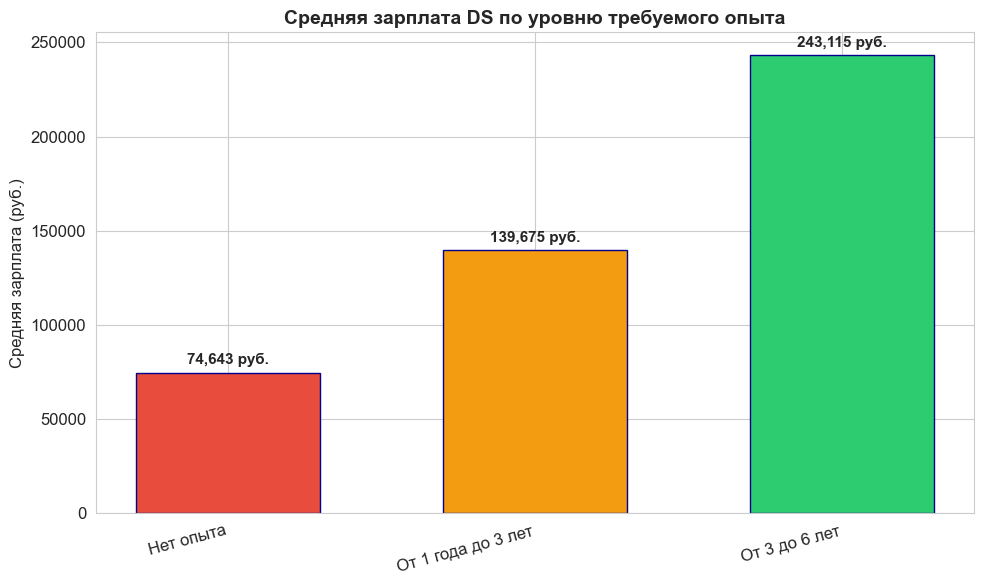

In [620]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Установим стиль для графиков
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12


salary_by_experience = pd.read_sql_query(query_6_6, connection)

print("Данные по зарплатам DS в зависимости от опыта:")
print(salary_by_experience.to_string(index=False))


plt.figure(figsize=(10, 6))
colors = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db']
bars = plt.bar(salary_by_experience['experience'], salary_by_experience['avg_salary'],
               color=colors[:len(salary_by_experience)], edgecolor='darkblue', width=0.6)
plt.ylabel('Средняя зарплата (руб.)', fontsize=12)
plt.title('Средняя зарплата DS по уровню требуемого опыта', fontsize=14, fontweight='bold')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 3000,
             f'{int(height):,} руб.', ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('ds_salary_by_experience_bar.png', dpi=150, bbox_inches='tight')
plt.show()


Выводы по графику:
* Наблюдается прямая зависимость между требуемым опытом и предлагаемой зарплатой: чем больше опыта требуется, тем выше зарплата. Это ожидаемый и логичный тренд.
* Самый значительный скачок происходит при переходе от junior-уровня к middle (почти удвоение зарплаты).
* Специалист с опытом 3-6 лет зарабатывает в 3,3 раза больше начинающего специалиста без опыта.

Общие выводы:
* Доля DS-вакансий: Всего 3,6% от рынка — нишевое, но растущее направление
* Junior-вакансии: Крайне мало (51) — высокий порог входа в профессию
* Python: Самый востребованный навык (357 вакансий)
* SQL: Важный дополнительный навык (229 вакансий)
* Среднее число навыков: 6,41 — широкий требуемый стек
* Зарплата (нет опыта): ~75 тыс. руб.
* Зарплата (3–6 лет): ~243 тыс. руб.
* Зарплатный рост: Более чем в 3 раза от junior к middle+

# Общий вывод по проекту

C:\Users\Klic\AppData\Local\Temp\ipykernel_4700\4258896088.py:27: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, connection)


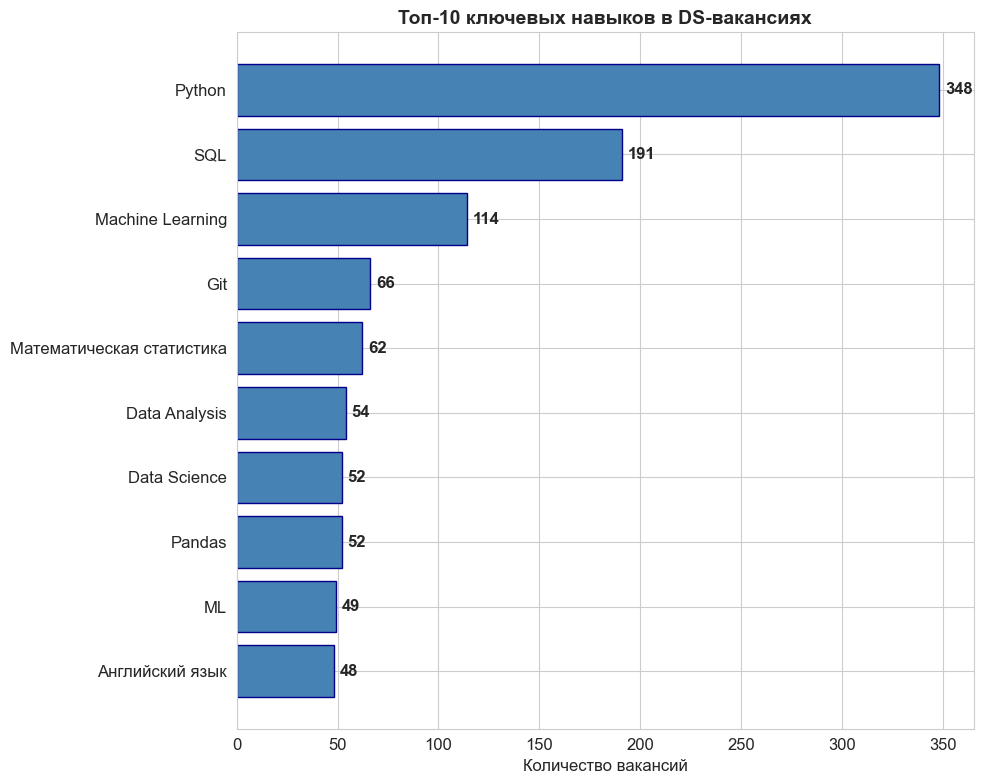


Топ-10 навыков в DS-вакансиях:
   • Python: 348 вакансий
   • SQL: 191 вакансий
   • Machine Learning: 114 вакансий
   • Git: 66 вакансий
   • Математическая статистика: 62 вакансий
   • Data Analysis: 54 вакансий
   • Data Science: 52 вакансий
   • Pandas: 52 вакансий
   • ML: 49 вакансий
   • Английский язык: 48 вакансий


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

query = """
SELECT
    TRIM(skill) as skill_name,
    COUNT(*) as frequency
FROM (
    SELECT
        unnest(string_to_array(v.key_skills, CHR(9))) as skill
    FROM public.vacancies v
    WHERE (LOWER(v.name) LIKE '%data scientist%'
          OR LOWER(v.name) LIKE '%data science%'
          OR LOWER(v.name) LIKE '%исследователь данных%'
          OR (v.name LIKE '%ML%' AND LOWER(v.name) NOT LIKE '%html%')
          OR LOWER(v.name) LIKE '%machine learning%'
          OR LOWER(v.name) LIKE '%машинн%обучен%')
        AND v.key_skills IS NOT NULL
        AND v.key_skills != ''
) AS skills_split
GROUP BY TRIM(skill)
ORDER BY frequency DESC
LIMIT 10;
"""

# Получаем данные
df = pd.read_sql_query(query, connection)
connection.close()

# Сортируем для горизонтального графика
df = df.sort_values('frequency', ascending=True)

# Строим график
plt.figure(figsize=(10, 8))
bars = plt.barh(df['skill_name'], df['frequency'],
                color='steelblue', edgecolor='darkblue')

plt.xlabel('Количество вакансий', fontsize=12)
plt.title('Топ-10 ключевых навыков в DS-вакансиях', fontsize=14, fontweight='bold')

# Добавляем цифры на столбцы
for bar in bars:
    width = bar.get_width()
    plt.text(width + 3, bar.get_y() + bar.get_height()/2,
             f'{int(width)}', ha='left', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('top10_ds_skills.png', dpi=150)
plt.show()

# Вывод данных
print("\nТоп-10 навыков в DS-вакансиях:")
for _, row in df[::-1].iterrows():
    print(f"   • {row['skill_name']}: {row['frequency']} вакансий")

Выводы:
* Рынок фрагментирован — большинство работодателей размещают мало вакансий (в среднем 2), а региональное распределение крайне неравномерно.
* Москва и Санкт-Петербург — абсолютные лидеры (более 8 000 вакансий, ~16,6% от всех)
* Высокая концентрация вакансий в столичных регионах
* Присутствуют крупные города ближнего зарубежья (Минск, Алматы)
* Только каждая вторая вакансия содержит информацию о зарплате
* Классический формат работы доминирует (72%), но удалёнка набирает популярность (16%)
* Основной спрос — на специалистов с опытом 1-3 года (более половины вакансий)
* Junior-вакансии составляют около 15% рынка
Рекомендации для начинающего дата-сайентиста:
* Изучить Python — обязательный навык
* Освоить SQL — требуется в 64% DS-вакансий
* Развивать широкий стек — работодатели ждут 6+ навыков
* Набраться терпения — junior-вакансий очень мало
* Рассмотреть стажировку — альтернативный путь входа
* Целевой ориентир по зарплате — через 1-3 года можно рассчитывать на 140 тыс. руб.
Рекомендации для иследования:
* Провести анализ дефицитных навыков
* Сравнить зарплаты DS с другими IT-специальностями
* Исследовать сезонность в публикации вакансий
* Проанализировать требования к образованию
* Начать с построения модели прогнозирования зарплаты и анализа дефицитных навыков — это даст максимальную практическую ценность при минимальных затратах на доработку данных.